In [15]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("../regression/salary_data_regression.csv")
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [3]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.drop_duplicates()
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

df_cleaned['YearsExperience'] = pd.to_numeric(df_cleaned['Years of Experience'], errors='coerce')
df_cleaned['Salary'] = pd.to_numeric(df_cleaned['Salary'], errors='coerce')

Original shape: (375, 6)
Cleaned shape: (324, 6)


In [4]:
df_cleaned = df_cleaned[(df_cleaned['Salary'] < df_cleaned['Salary'].quantile(0.95))]

In [5]:
# Basic info
print(df_cleaned.info())
print(df_cleaned.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 371
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  297 non-null    float64
 1   Gender               297 non-null    object 
 2   Education Level      297 non-null    object 
 3   Job Title            297 non-null    object 
 4   Years of Experience  297 non-null    float64
 5   Salary               297 non-null    float64
 6   YearsExperience      297 non-null    float64
dtypes: float64(4), object(3)
memory usage: 18.6+ KB
None
              Age  Years of Experience         Salary  YearsExperience
count  297.000000           297.000000     297.000000       297.000000
mean    36.363636             9.111111   91819.360269         9.111111
std      6.584874             6.080355   41786.702235         6.080355
min     23.000000             0.000000     350.000000         0.000000
25%     31.000000             3.000000

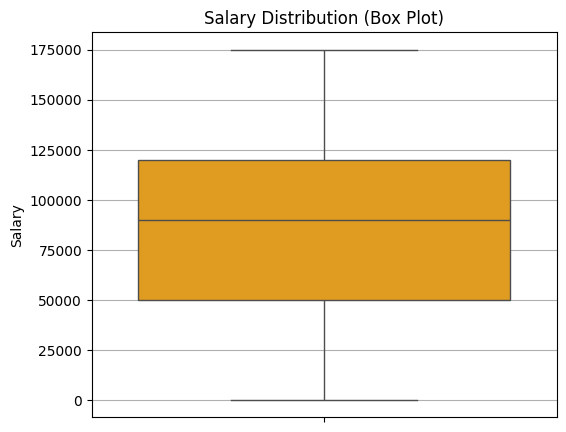

In [6]:
# Box Plot - Salary Distribution
plt.figure(figsize=(6, 5))
sns.boxplot(y='Salary', data=df_cleaned, color='orange')
plt.title('Salary Distribution (Box Plot)')
plt.ylabel('Salary')
plt.grid(True, axis='y')
plt.show()

/var/folders/nw/c745mgyj79lf4r0gkq4qslmr0000gn/T/ipykernel_12388/2118500508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Salary', data=avg_salary_by_gender, palette='Set2')


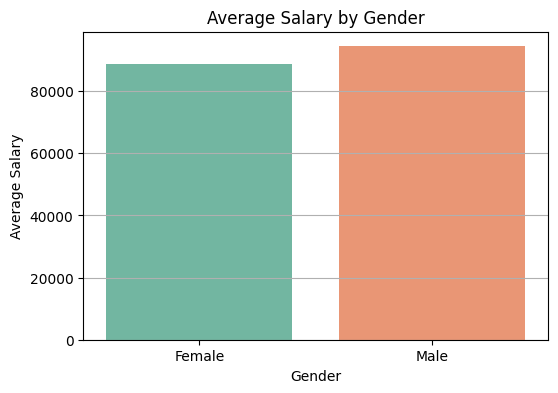

In [7]:
# Group by Gender and compute average salary
avg_salary_by_gender = df_cleaned.groupby('Gender')['Salary'].mean().reset_index()

# Bar plot - Average Salary by Gender
plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Salary', data=avg_salary_by_gender, palette='Set2')
plt.title('Average Salary by Gender')
plt.ylabel('Average Salary')
plt.xlabel('Gender')
plt.grid(axis='y')
plt.show()


--- Model Comparison Table ---
               Model           MAE           MSE  R2 Score
0  Linear Regression  14753.690807  3.416179e+08  0.806116
1      Random Forest  14616.542759  3.684544e+08  0.790885

--- Prediction Samples ---
   Actual Salary  LR Predicted  RF Predicted
0        40000.0      46802.64      42562.54
1        50000.0      43647.34      34592.23
2        70000.0     103598.07     102366.92
3        50000.0      59423.85      57904.42
4       120000.0     109908.67     106203.31
5       135000.0     166704.10     164645.71
6       130000.0     135151.08     148273.59
7        45000.0      43647.34      34592.23
8        75000.0      53113.25      51355.29
9       140000.0     147772.29     140964.95


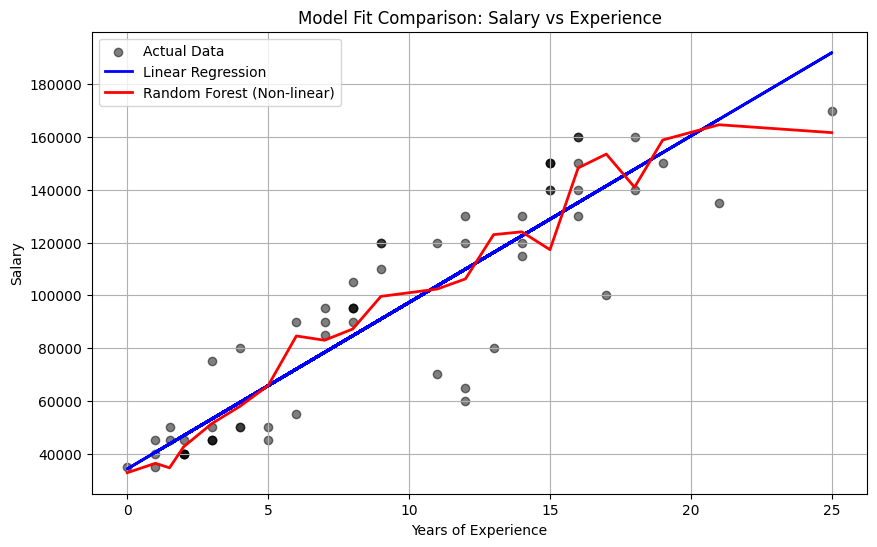

In [16]:
# Prepare Data for Modeling
# Using 'Years of Experience' to predict 'Salary'
X = df_cleaned[['Years of Experience']]
y = df_cleaned['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Build Model 2: Random Forest Regressor (The second model for comparison)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 7. Evaluate and Compare Results
results = {
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf)],
    "MSE": [mean_squared_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_rf)],
    "R2 Score": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]
}

comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison Table ---")
print(comparison_df)

# Make Predictions (Sample of first 10 test cases)
comparison_preds = pd.DataFrame({
    "Actual Salary": y_test.values,
    "LR Predicted": np.round(y_pred_lr, 2),
    "RF Predicted": np.round(y_pred_rf, 2)
}).head(10)

print("\n--- Prediction Samples ---")
print(comparison_preds)

# Visualization of Model Fit Comparison
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', alpha=0.5, label='Actual Data')

# Linear Regression Line
plt.plot(X_test, y_pred_lr, color='blue', linewidth=2, label='Linear Regression')

# Random Forest Line (Sorted for visualization)
X_test_sorted = X_test.sort_values(by='Years of Experience')
y_pred_rf_sorted = rf_model.predict(X_test_sorted)
plt.plot(X_test_sorted, y_pred_rf_sorted, color='red', linewidth=2, label='Random Forest (Non-linear)')

plt.title('Model Fit Comparison: Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()